[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/naylaartha2-png/TUGAS-UAS-STATISTIKA/blob/main/Nayla_Artha_Mevia_Suma_F5212510009.ipynb)

# Prediksi Risiko Penduduk Terkena Tindak Pidana Berdasarkan Jumlah Kejahatan, Persentase Penyelesaian, dan Selang Waktu Terjadinya Kejahatan Menurut Provinsi di Indonesia Tahun 2017–2021 Menggunakan Regresi Linear Berganda



#  Data Collecting

Dataset yang digunakan merupakan data kejahatan menurut provinsi di Indonesia dari tahun 2017 hingga 2021 berdasarkan data dari BPS (Badan Pusat Statistik). Dataset ini memuat informasi mengenai jumlah kejahatan, risiko penduduk terkena tindak pidana per 100.000 penduduk, persentase penyelesaian kejahatan, dan selang waktu terjadinya kejahatan di setiap provinsi.

**Variabel yang digunakan:**
- **Variabel Target (Y):** `Risiko_per_100rb` — Risiko penduduk terkena tindak pidana per 100.000 penduduk
- **Variabel Prediktor (X):**
  - `Jml_Kejahatan` — Jumlah kejahatan yang terjadi
  - `Pct_Selesai` — Persentase penyelesaian perkara kejahatan (%)
  - `Selang_Waktu` — Selang waktu terjadinya kejahatan (hari)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

print("Library berhasil diimport!")

Library berhasil diimport!


In [ ]:
file_path = "data_kejahatan_bersih.csv"
df = pd.read_csv(file_path)

print("Dataset berhasil dimuat!")

Dataset berhasil dimuat!


#  Exploratory Data Analysis (EDA)

Pada tahap ini, kita akan mengeksplorasi dataset untuk memahami struktur data, distribusi variabel, dan hubungan antar variabel sebelum membangun model prediksi.

In [ ]:
print("=== 5 Data Pertama ===")
df.head()

=== 5 Data Pertama ===


,Tahun,Provinsi,Jml_Kejahatan,Risiko_per_100rb,Pct_Selesai,Selang_Waktu
0,2017,Aceh,8885.0,171.0,27.19,59.0
1,2017,Sumatera Utara,39867.0,280.0,67.30,13.0
2,2017,Sumatera Barat,13205.0,248.0,42.88,39.0
3,2017,Riau,6869.0,103.0,54.33,116.0
4,2017,Jambi,9531.0,271.0,65.20,55.0


In [ ]:
print("=== Statistik Deskriptif ===")
df.describe()

=== Statistik Deskriptif ===


,Tahun,Jml_Kejahatan,Risiko_per_100rb,Pct_Selesai,Selang_Waktu
count,169.000000,169.000000,169.000000,169.000000,169.000000
mean,2019.011834,8206.840237,147.609467,64.547929,183.142012
std,1.414164,8247.320644,77.117421,17.755668,300.987092
min,2017.000000,396.000000,15.000000,10.110000,0.000000
25%,2018.000000,3086.000000,94.000000,54.580000,19.000000
50%,2019.000000,6020.000000,137.000000,66.830000,112.000000
75%,2020.000000,9127.000000,190.000000,76.090000,231.000000
max,2021.000000,39867.000000,416.000000,100.000000,2217.000000


In [ ]:
print("=== Informasi Dataset ===")
df.info()

=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169 entries, 0 to 168
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Tahun             169 non-null    int64  
 1   Provinsi          169 non-null    object 
 2   Jml_Kejahatan     169 non-null    float64
 3   Risiko_per_100rb  169 non-null    float64
 4   Pct_Selesai       169 non-null    float64
 5   Selang_Waktu      169 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 8.1+ KB


In [ ]:
print(f"Jumlah baris (observasi) : {df.shape[0]}")
print(f"Jumlah kolom (variabel)  : {df.shape[1]}")
print(f"Jumlah provinsi          : {df['Provinsi'].nunique()}")
print(f"Rentang tahun            : {df['Tahun'].min()} - {df['Tahun'].max()}")

Jumlah baris (observasi) : 169
Jumlah kolom (variabel)  : 6
Jumlah provinsi          : 34
Rentang tahun            : 2017 - 2021


In [ ]:
print("=== Jumlah Nilai Kosong per Kolom ===")
print(df.isnull().sum())

=== Jumlah Nilai Kosong per Kolom ===
Tahun               0
Provinsi            0
Jml_Kejahatan       0
Risiko_per_100rb    0
Pct_Selesai         0
Selang_Waktu        0
dtype: int64


In [ ]:
print(f"Jumlah data duplikat: {df.duplicated().sum()}")

Jumlah data duplikat: 0


==== Deteksi Outlier dengan IQR pada kolom Risiko_per_100rb ====
Batas Bawah : -50.0
Batas Atas  : 334.0
Jumlah Risiko_per_100rb Outlier : 3 baris dari total 169 baris data


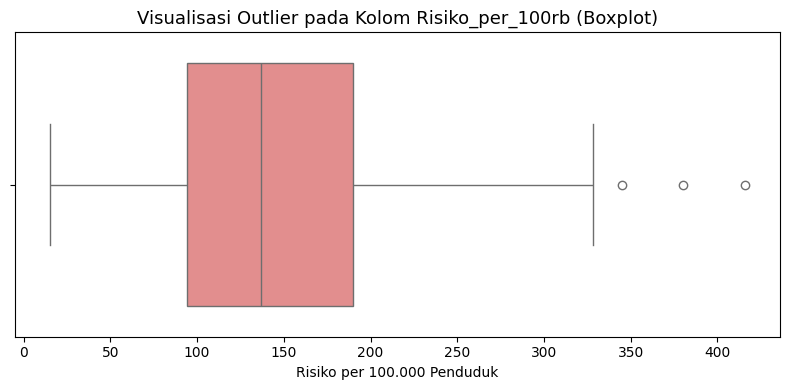

In [ ]:
kolom_target = 'Risiko_per_100rb'

print(f"==== Deteksi Outlier dengan IQR pada kolom {kolom_target} ====")

Q1 = df[kolom_target].quantile(0.25)
Q3 = df[kolom_target].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[kolom_target] < lower_bound) | (df[kolom_target] > upper_bound)]
print(f"Batas Bawah : {lower_bound}")
print(f"Batas Atas  : {upper_bound}")
print(f"Jumlah {kolom_target} Outlier : {len(outliers)} baris dari total {len(df)} baris data")

plt.figure(figsize=(8, 4))
sns.boxplot(x=df[kolom_target], color='lightcoral')
plt.title(f'Visualisasi Outlier pada Kolom {kolom_target} (Boxplot)', fontsize=13)
plt.xlabel('Risiko per 100.000 Penduduk')
plt.tight_layout()
plt.show()

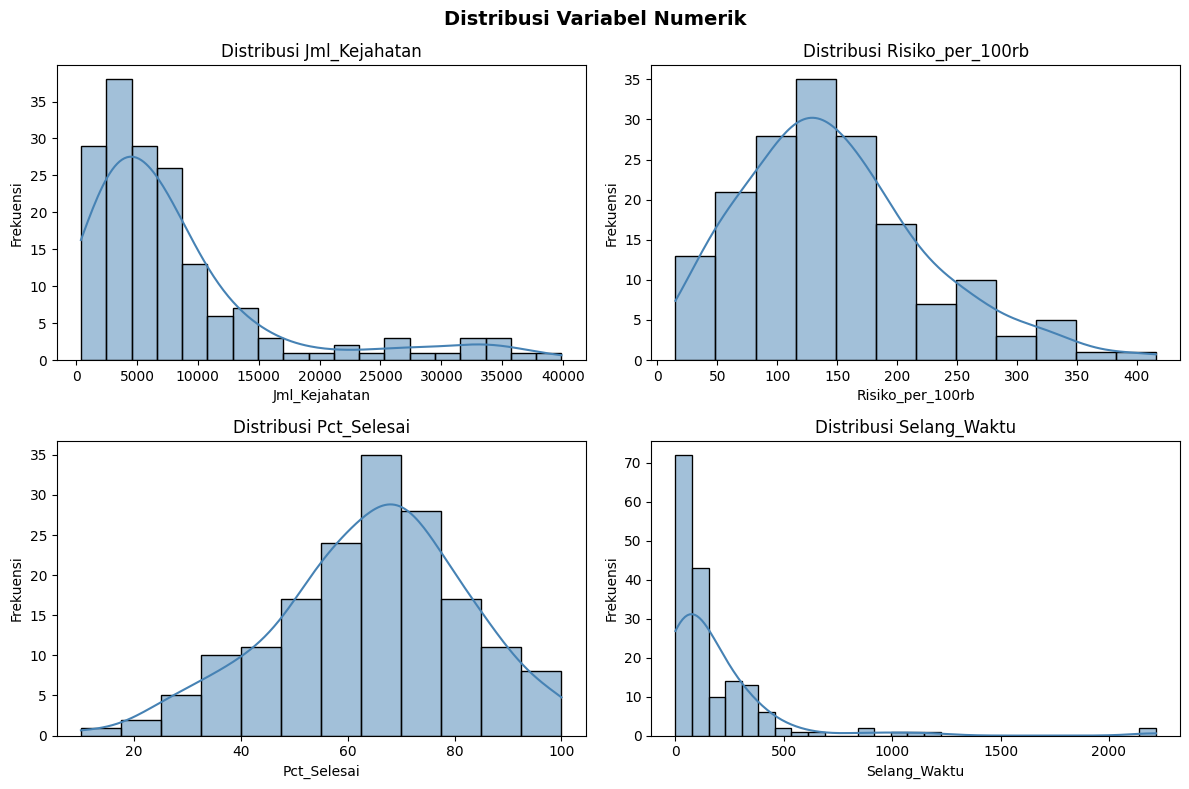

In [ ]:
numerik_cols = ['Jml_Kejahatan', 'Risiko_per_100rb', 'Pct_Selesai', 'Selang_Waktu']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribusi Variabel Numerik', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), numerik_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribusi {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

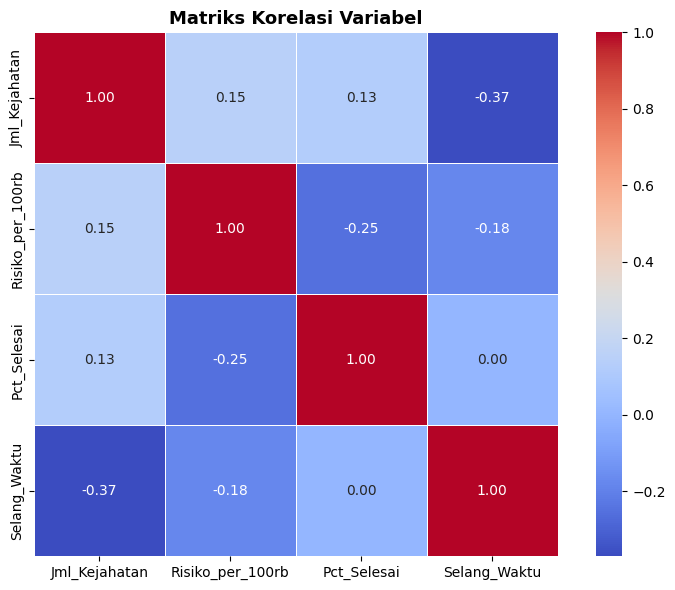


=== Nilai Korelasi terhadap Risiko_per_100rb ===
Risiko_per_100rb    1.000000
Jml_Kejahatan       0.145203
Selang_Waktu       -0.178010
Pct_Selesai        -0.253014
Name: Risiko_per_100rb, dtype: float64


In [ ]:
plt.figure(figsize=(8, 6))
corr_matrix = df[numerik_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Matriks Korelasi Variabel', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== Nilai Korelasi terhadap Risiko_per_100rb ===")
print(corr_matrix['Risiko_per_100rb'].sort_values(ascending=False))

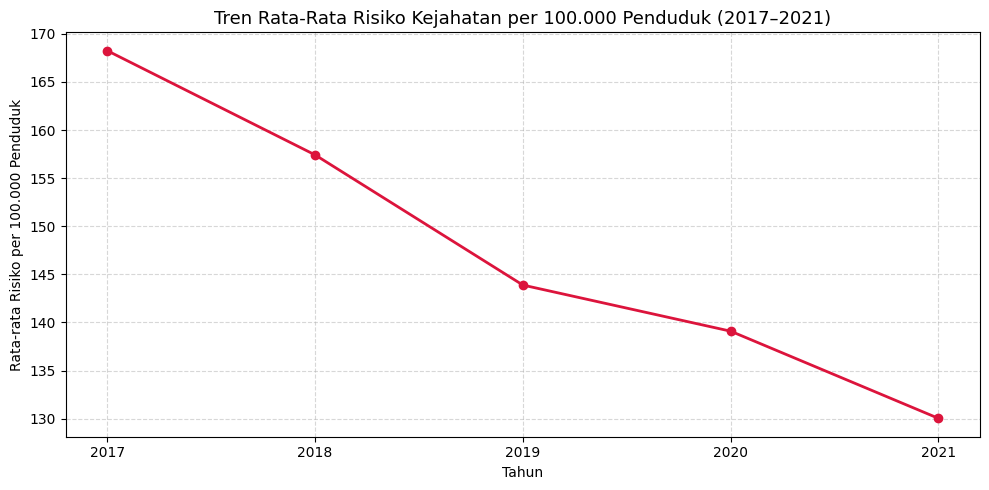

In [ ]:
plt.figure(figsize=(10, 5))
trend = df.groupby('Tahun')['Risiko_per_100rb'].mean().reset_index()
plt.plot(trend['Tahun'], trend['Risiko_per_100rb'], marker='o', color='crimson', linewidth=2)
plt.title('Tren Rata-Rata Risiko Kejahatan per 100.000 Penduduk (2017–2021)', fontsize=13)
plt.xlabel('Tahun')
plt.ylabel('Rata-rata Risiko per 100.000 Penduduk')
plt.xticks(trend['Tahun'].astype(int))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

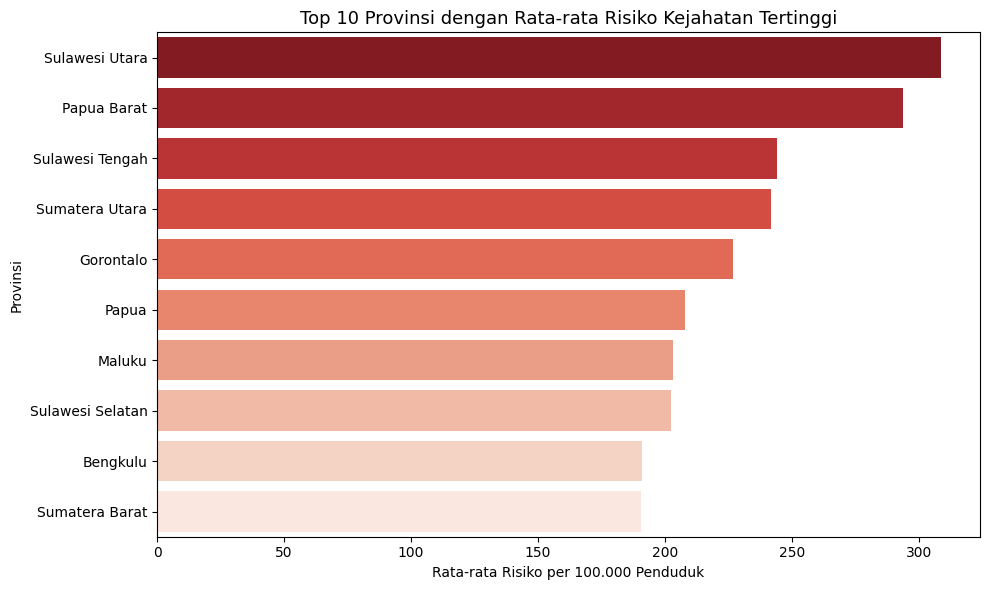

In [ ]:
# Top 10 provinsi dengan rata-rata risiko kejahatan tertinggi
plt.figure(figsize=(10, 6))
top10 = df.groupby('Provinsi')['Risiko_per_100rb'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top10.values, y=top10.index, palette='Reds_r')
plt.title('Top 10 Provinsi dengan Rata-rata Risiko Kejahatan Tertinggi', fontsize=13)
plt.xlabel('Rata-rata Risiko per 100.000 Penduduk')
plt.ylabel('Provinsi')
plt.tight_layout()
plt.show()

#  Data Preprocessing

Pada tahap ini dilakukan persiapan data sebelum dimasukkan ke dalam model, meliputi penanganan outlier, pemilihan fitur, dan pembagian data menjadi data latih dan data uji.

In [ ]:
print(f"Jumlah data sebelum pembersihan outlier: {len(df)}")

df_clean = df[(df['Risiko_per_100rb'] >= lower_bound) & (df['Risiko_per_100rb'] <= upper_bound)].copy()

print(f"Jumlah data setelah pembersihan outlier: {len(df_clean)}")
print(f"Data yang dihapus: {len(df) - len(df_clean)} baris")

Jumlah data sebelum pembersihan outlier: 169
Jumlah data setelah pembersihan outlier: 166
Data yang dihapus: 3 baris


In [ ]:
X = df_clean[['Jml_Kejahatan', 'Pct_Selesai', 'Selang_Waktu']]
y = df_clean['Risiko_per_100rb']

print("=== Variabel Prediktor (X) ===")
print(X.head())
print(f"\nShape X: {X.shape}")
print(f"\n=== Variabel Target (y) ===")
print(y.head())

=== Variabel Prediktor (X) ===
   Jml_Kejahatan  Pct_Selesai  Selang_Waktu
0         8885.0        27.19          59.0
1        39867.0        67.30          13.0
2        13205.0        42.88          39.0
3         6869.0        54.33         116.0
4         9531.0        65.20          55.0

Shape X: (166, 3)

=== Variabel Target (y) ===
0    171.0
1    280.0
2    248.0
3    103.0
4    271.0
Name: Risiko_per_100rb, dtype: float64


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("=== Data Setelah Standardisasi ===")
print(X_scaled.describe().round(2))

=== Data Setelah Standardisasi ===
       Jml_Kejahatan  Pct_Selesai  Selang_Waktu
count         166.00       166.00        166.00
mean            0.00        -0.00         -0.00
std             1.00         1.00          1.00
min            -0.94        -3.12         -0.61
25%            -0.62        -0.58         -0.55
50%            -0.27         0.12         -0.24
75%             0.09         0.64          0.16
max             3.82         2.00          6.72


In [ ]:
# Membagi data menjadi data latih (train) dan data uji (test)
# 80% data latih dan 20% data uji
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Jumlah data latih (train) : {X_train.shape[0]} baris")
print(f"Jumlah data uji  (test)   : {X_test.shape[0]} baris")

Jumlah data latih (train) : 132 baris
Jumlah data uji  (test)   : 34 baris


#  Model Training

Pada tahap ini, model **Regresi Linear Berganda** dilatih menggunakan data latih. Regresi linear berganda digunakan untuk memodelkan hubungan antara satu variabel dependen (risiko kejahatan) dengan dua atau lebih variabel independen (jumlah kejahatan, persentase penyelesaian, dan selang waktu).

Persamaan umum regresi linear berganda:

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_3 + \varepsilon$$

Di mana:
- $Y$ = Risiko per 100.000 penduduk
- $X_1$ = Jumlah Kejahatan
- $X_2$ = Persentase Penyelesaian
- $X_3$ = Selang Waktu
- $\beta_0$ = Intercept (konstanta)
- $\beta_1, \beta_2, \beta_3$ = Koefisien regresi

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

print("=== PERSAMAAN REGRESI LINEAR BERGANDA ===")
print(f"Intercept (β₀) : {model.intercept_:.4f}")
print()
for nama, koef in zip(X.columns, model.coef_):
    print(f"Koefisien {nama} : {koef:.4f}")

y_pred = model.predict(X_test)

=== PERSAMAAN REGRESI LINEAR BERGANDA ===
Intercept (β₀) : 147.3578

Koefisien Jml_Kejahatan : 14.1761
Koefisien Pct_Selesai : -16.8250
Koefisien Selang_Waktu : -6.8919


In [ ]:
b0 = model.intercept_
b1, b2, b3 = model.coef_

print("=== PERSAMAAN MODEL ===")
print(f"Risiko_per_100rb = {b0:.4f}")
print(f"                 + ({b1:.4f}) × Jml_Kejahatan")
print(f"                 + ({b2:.4f}) × Pct_Selesai")
print(f"                 + ({b3:.4f}) × Selang_Waktu")

=== PERSAMAAN MODEL ===
Risiko_per_100rb = 147.3578
                 + (14.1761) × Jml_Kejahatan
                 + (-16.8250) × Pct_Selesai
                 + (-6.8919) × Selang_Waktu


#  Visualisasi Hasil Prediksi

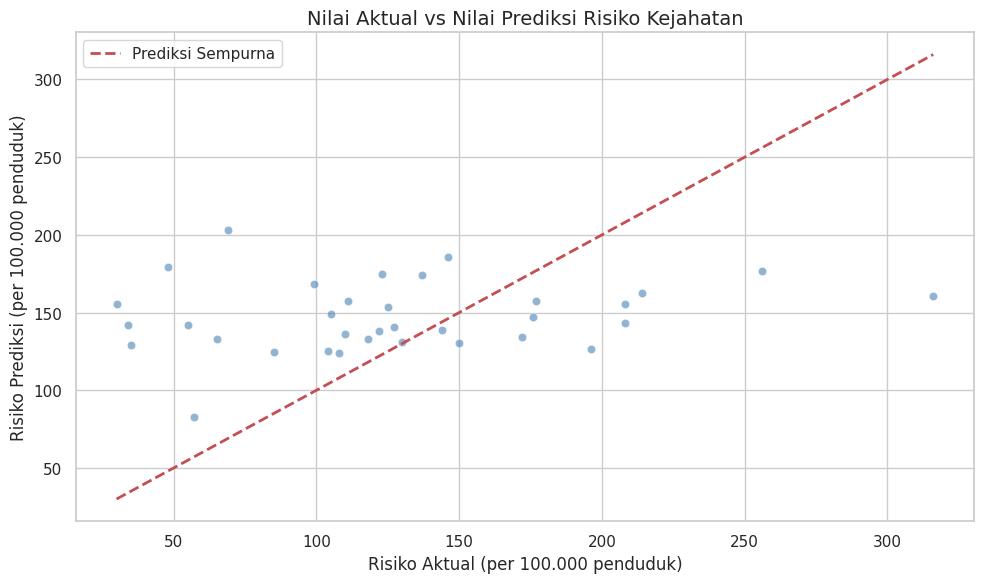

In [ ]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='white', linewidth=0.5)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Prediksi Sempurna')

plt.title('Nilai Aktual vs Nilai Prediksi Risiko Kejahatan', fontsize=14)
plt.xlabel('Risiko Aktual (per 100.000 penduduk)', fontsize=12)
plt.ylabel('Risiko Prediksi (per 100.000 penduduk)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

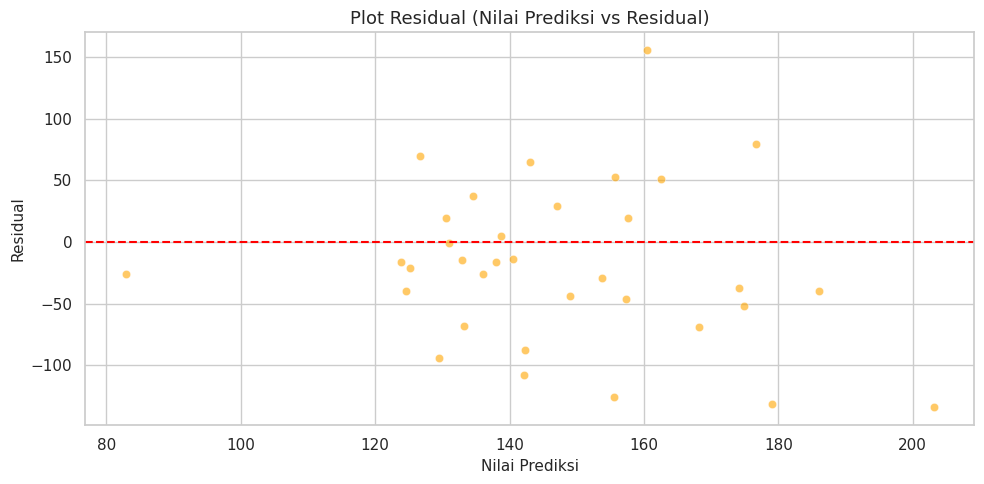

In [ ]:
residual = y_test.values - y_pred

plt.figure(figsize=(10, 5))
plt.scatter(y_pred, residual, alpha=0.6, color='orange', edgecolors='white', linewidth=0.5)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.title('Plot Residual (Nilai Prediksi vs Residual)', fontsize=13)
plt.xlabel('Nilai Prediksi', fontsize=11)
plt.ylabel('Residual', fontsize=11)
plt.tight_layout()
plt.show()

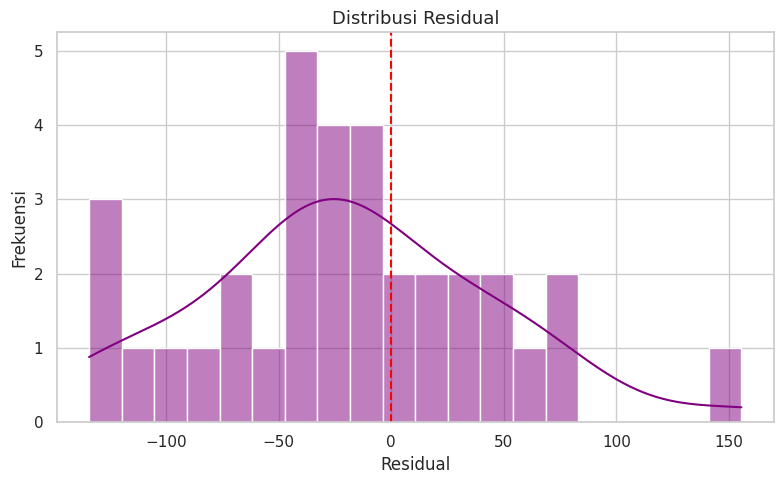

In [ ]:
# VISUALISASI 3: Distribusi Residual
# Distribusi residual yang mendekati normal menunjukkan asumsi linearitas terpenuhi
plt.figure(figsize=(8, 5))
sns.histplot(residual, kde=True, color='purple', bins=20)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
plt.title('Distribusi Residual', fontsize=13)
plt.xlabel('Residual')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

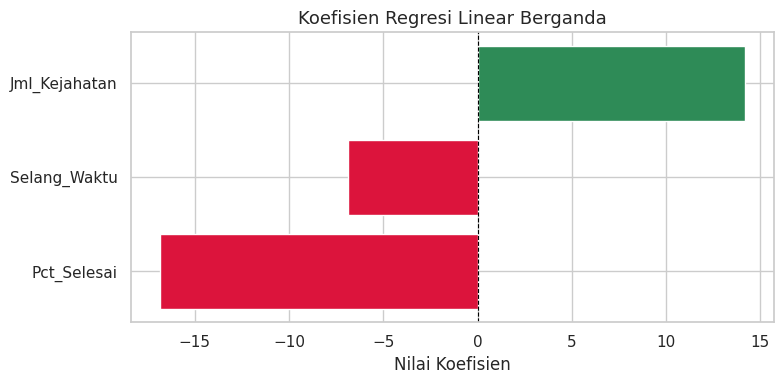

Interpretasi:
- Koefisien positif (hijau) → variabel meningkatkan risiko kejahatan
- Koefisien negatif (merah) → variabel menurunkan risiko kejahatan


In [ ]:
koef_df = pd.DataFrame({
    'Variabel': X.columns,
    'Koefisien': model.coef_
}).sort_values('Koefisien', ascending=True)

plt.figure(figsize=(8, 4))
colors = ['crimson' if k < 0 else 'seagreen' for k in koef_df['Koefisien']]
plt.barh(koef_df['Variabel'], koef_df['Koefisien'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.title('Koefisien Regresi Linear Berganda', fontsize=13)
plt.xlabel('Nilai Koefisien')
plt.tight_layout()
plt.show()

print("Interpretasi:")
print("- Koefisien positif (hijau) → variabel meningkatkan risiko kejahatan")
print("- Koefisien negatif (merah) → variabel menurunkan risiko kejahatan")

#  Evaluasi Model

Evaluasi model dilakukan untuk mengukur seberapa baik model dalam memprediksi risiko kejahatan. Metrik yang digunakan:

| Metrik | Keterangan |
| ------ | ----------- |
| MAE    | Mean Absolute Error — rata-rata kesalahan absolut antara nilai aktual dan prediksi |
| MSE    | Mean Squared Error — rata-rata kuadrat kesalahan; memberi hukuman lebih pada error besar |
| RMSE   | Root Mean Squared Error — akar dari MSE; mudah diinterpretasikan karena satuannya sama dengan target |
| R²     | Koefisien determinasi — proporsi variansi target yang dapat dijelaskan oleh model (0–1, semakin mendekati 1 semakin baik) |

In [ ]:
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\n=== EVALUASI MODEL REGRESI LINEAR BERGANDA ===")
print(f"R²   (Koefisien Determinasi) : {r2:.4f}  ({r2*100:.2f}%)")
print(f"MAE  (Mean Absolute Error)   : {mae:.4f}")
print(f"MSE  (Mean Squared Error)    : {mse:.4f}")
print(f"RMSE (Root MSE)              : {rmse:.4f}")

print("\n=== INTERPRETASI ===")
if r2 >= 0.7:
    print(f"Model memiliki R² = {r2:.2f}, artinya {r2*100:.1f}% variasi risiko kejahatan")
    print("dapat dijelaskan oleh variabel prediktor yang digunakan. Model CUKUP BAIK.")
elif r2 >= 0.5:
    print(f"Model memiliki R² = {r2:.2f}, artinya {r2*100:.1f}% variasi risiko kejahatan")
    print("dapat dijelaskan oleh variabel prediktor. Model CUKUP MODERAT.")
else:
    print(f"Model memiliki R² = {r2:.2f}, artinya {r2*100:.1f}% variasi risiko kejahatan")
    print("dapat dijelaskan oleh variabel prediktor. Perlu penambahan fitur atau transformasi data.")


=== EVALUASI MODEL REGRESI LINEAR BERGANDA ===
R²   (Koefisien Determinasi) : -0.0759  (-7.59%)
MAE  (Mean Absolute Error)   : 53.6213
MSE  (Mean Squared Error)    : 4450.1062
RMSE (Root MSE)              : 66.7091

=== INTERPRETASI ===
Model memiliki R² = -0.08, artinya -7.6% variasi risiko kejahatan
dapat dijelaskan oleh variabel prediktor. Perlu penambahan fitur atau transformasi data.


In [ ]:
hasil_uji = pd.DataFrame({
    'Risiko Aktual': y_test.values[:10],
    'Risiko Prediksi': np.round(y_pred[:10], 2),
    'Selisih (Error)': np.abs(y_test.values[:10] - y_pred[:10]).round(2)
})

print("=== CONTOH HASIL PREDIKSI (10 Data Pertama) ===")
print(hasil_uji.to_string(index=False))

=== CONTOH HASIL PREDIKSI (10 Data Pertama) ===
 Risiko Aktual  Risiko Prediksi  Selisih (Error)
         150.0           130.59            19.41
         104.0           125.13            21.13
          69.0           203.11           134.11
         316.0           160.48           155.52
         214.0           162.59            51.41
          65.0           133.15            68.15
         172.0           134.55            37.45
         111.0           157.34            46.34
         177.0           157.61            19.39
         105.0           148.96            43.96


#  Deployment / Prediksi Data Baru

Pada tahap ini, model yang telah dilatih digunakan untuk memprediksi risiko kejahatan berdasarkan input data baru dari pengguna.

In [ ]:
# PREDIKSI RISIKO KEJAHATAN BERDASARKAN INPUT PENGGUNA

print("=== SISTEM PREDIKSI RISIKO KEJAHATAN ===")
print("Masukkan data berikut untuk memprediksi risiko penduduk terkena tindak pidana:")
print()

jml_kejahatan = 7000    # Jumlah kejahatan
pct_selesai   = 65.0    # Persentase penyelesaian perkara (%)
selang_waktu  = 100.0   # Selang waktu kejahatan (hari)

print(f"Input Data Baru:")
print(f"  Jumlah Kejahatan        : {jml_kejahatan}")
print(f"  Persentase Penyelesaian : {pct_selesai}%")
print(f"  Selang Waktu Kejahatan  : {selang_waktu} hari")

data_baru = pd.DataFrame([{
    'Jml_Kejahatan': jml_kejahatan,
    'Pct_Selesai'  : pct_selesai,
    'Selang_Waktu' : selang_waktu
}])

data_baru_scaled = scaler.transform(data_baru)

prediksi = model.predict(data_baru_scaled)[0]

print()
print("=" * 45)
print(f"HASIL PREDIKSI:")
print(f"  Risiko per 100.000 Penduduk : {prediksi:.2f} orang")
print("=" * 45)

rata_nasional = df['Risiko_per_100rb'].mean()
print(f"\nRata-rata nasional (2017-2021) : {rata_nasional:.2f} orang per 100.000 penduduk")

if prediksi > rata_nasional:
    print(f"Prediksi MELEBIHI rata-rata nasional → Risiko TINGGI")
else:
    print(f"Prediksi DI BAWAH rata-rata nasional → Risiko RENDAH")

=== SISTEM PREDIKSI RISIKO KEJAHATAN ===
Masukkan data berikut untuk memprediksi risiko penduduk terkena tindak pidana:

Input Data Baru:
  Jumlah Kejahatan        : 7000
  Persentase Penyelesaian : 65.0%
  Selang Waktu Kejahatan  : 100.0 hari

HASIL PREDIKSI:
  Risiko per 100.000 Penduduk : 147.16 orang

Rata-rata nasional (2017-2021) : 147.61 orang per 100.000 penduduk
Prediksi DI BAWAH rata-rata nasional → Risiko RENDAH


In [ ]:
# KESIMPULAN

print("=" * 55)
print("KESIMPULAN ANALISIS REGRESI LINEAR BERGANDA")
print("=" * 55)
print()
print("Judul:")
print("  Prediksi Risiko Penduduk Terkena Tindak Pidana")
print("  Menurut Provinsi di Indonesia Tahun 2017–2021")
print()
print("Variabel Prediktor (X):")
print("  1. Jumlah Kejahatan (Jml_Kejahatan)")
print("  2. Persentase Penyelesaian Perkara (Pct_Selesai)")
print("  3. Selang Waktu Terjadinya Kejahatan (Selang_Waktu)")
print()
print("Variabel Target (Y):")
print("  Risiko per 100.000 Penduduk (Risiko_per_100rb)")
print()
print("Persamaan Model:")
print(f"  Y = {b0:.4f} + ({b1:.4f})×X₁ + ({b2:.4f})×X₂ + ({b3:.4f})×X₃")
print()
print("Hasil Evaluasi:")
print(f"  R²   = {r2:.4f}  → Model menjelaskan {r2*100:.2f}% variansi data")
print(f"  MAE  = {mae:.4f}  → Rata-rata kesalahan absolut")
print(f"  RMSE = {rmse:.4f}  → Ukuran error yang mudah diinterpretasikan")
print()
print("=" * 55)

KESIMPULAN ANALISIS REGRESI LINEAR BERGANDA

Judul:
  Prediksi Risiko Penduduk Terkena Tindak Pidana
  Menurut Provinsi di Indonesia Tahun 2017–2021

Variabel Prediktor (X):
  1. Jumlah Kejahatan (Jml_Kejahatan)
  2. Persentase Penyelesaian Perkara (Pct_Selesai)
  3. Selang Waktu Terjadinya Kejahatan (Selang_Waktu)

Variabel Target (Y):
  Risiko per 100.000 Penduduk (Risiko_per_100rb)

Persamaan Model:
  Y = 147.3578 + (14.1761)×X₁ + (-16.8250)×X₂ + (-6.8919)×X₃

Hasil Evaluasi:
  R²   = -0.0759  → Model menjelaskan -7.59% variansi data
  MAE  = 53.6213  → Rata-rata kesalahan absolut
  RMSE = 66.7091  → Ukuran error yang mudah diinterpretasikan

